In [1825]:
# Data handling and manipulation library
import pandas as pd

# Library for numerical operations in Python
import numpy as np

# Visualizations library
import matplotlib.pyplot as plt

# Exploratory visualizations library
import seaborn as sns

# Statistical functions library
from scipy import stats

# ml libraries
from sklearn.preprocessing import StandardScaler
from factor_analyzer.factor_analyzer import calculate_kmo, Rotator
from sklearn.decomposition import PCA


In [1826]:
import pandas as pd
import os

# Map dansk → ASCII
replace_map = {
    "æ": "ae", "Æ": "Ae",
    "ø": "oe", "Ø": "Oe",
    "å": "aa", "Å": "Aa"
}

def remove_danish_chars(df):
    return df.replace(replace_map, regex=True)

# Liste over filer
files = [
    "../files/T2D.csv",
    "../files/Morbidly_Obese.csv",
    "../files/Longterm_Disease.csv",
    "../files/Fraction_Blood_Clot.csv",
    "../files/Education_Long.csv",
    "../files/WHO_Minimum_Physical_Activity.csv",
    "../files/Life_Expectancy.csv",
    "../files/Absence.csv"
]

for path in files:
    df = pd.read_csv(path, sep=";", encoding="latin-1", dtype=str)  # læs alt som tekst
    df = remove_danish_chars(df)
    
    # Gem som ny fil (kan overskrive hvis du vil)
    cleaned_path = path.replace(".csv", ".csv")
    df.to_csv(cleaned_path, sep=";", index=False, encoding="latin-1")
    
    print("Renset:", cleaned_path)

Renset: ../files/T2D.csv
Renset: ../files/Morbidly_Obese.csv
Renset: ../files/Longterm_Disease.csv
Renset: ../files/Fraction_Blood_Clot.csv
Renset: ../files/Education_Long.csv
Renset: ../files/WHO_Minimum_Physical_Activity.csv
Renset: ../files/Life_Expectancy.csv
Renset: ../files/Absence.csv


In [1827]:
# === 2) Load raw CSVs (semicolon; Danish chars) ===
# If your files are elsewhere, adjust the paths below.
t2d  = pd.read_csv("../files/T2D.csv", sep=";", encoding="latin-1")
mob  = pd.read_csv("../files/Morbidly_Obese.csv", sep=";", encoding="latin-1")
ltd  = pd.read_csv("../files/Longterm_Disease.csv", sep=";", encoding="latin-1")
fbc  = pd.read_csv("../files/Fraction_Blood_Clot.csv", sep=";", encoding="latin-1")
edu  = pd.read_csv("../files/Education_Long.csv", sep=";", encoding="latin-1")
who  = pd.read_csv("../files/WHO_Minimum_Physical_Activity.csv", sep=";", encoding="latin-1")
life = pd.read_csv("../files/Life_Expectancy.csv", sep=";", encoding="latin-1")
absn = pd.read_csv("../files/Absence.csv", sep=";", encoding="latin-1")

# Quick inspect (as in exercises)
print(ltd.shape);  print(ltd.head(3))

(60, 3)
   brick_nr           brick               anddel
0       101        Bornholm               0,4065
1       102          Amager  0,32666666666666666
2       103  Noerrebro/City                0,305


In [1828]:
# === 3) Standardize column names (lowercase, strip) ===
for df in [t2d, mob, ltd, fbc, edu, who, life, absn]:
    df.columns = [c.strip().lower() for c in df.columns]

# Ensure key 'brick_nr' is numeric (Int64) for safe merges
for df in [t2d, mob, ltd, fbc, edu, who, life, absn]:
    if "brick_nr" in df.columns:
        df["brick_nr"] = pd.to_numeric(df["brick_nr"], errors="coerce").astype("Int64")

In [1829]:
print(ltd.shape);  print(ltd.head(3))

(60, 3)
   brick_nr           brick               anddel
0       101        Bornholm               0,4065
1       102          Amager  0,32666666666666666
2       103  Noerrebro/City                0,305


In [1830]:
# === 4) Add dataset suffixes so column origins are clear ===
t2d = t2d.rename(columns={k: f"{k}_t2d" for k in t2d.columns if k not in ["brick_nr","brick"]})
mob = mob.rename(columns={k: f"{k}_morbidly_obese" for k in mob.columns if k not in ["brick_nr","brick"]})
ltd = ltd.rename(columns={k: f"{k}_longterm_disease" for k in ltd.columns if k not in ["brick_nr","brick"]})
fbc = fbc.rename(columns={k: f"{k}_fraction_blood_clot" for k in fbc.columns if k not in ["brick_nr","brick"]})
edu = edu.rename(columns={k: f"{k}_education_long" for k in edu.columns if k not in ["brick_nr","brick"]})
who = who.rename(columns={k: f"{k}_who_minimum_physical_activity" for k in who.columns if k not in ["brick_nr","brick"]})
life = life.rename(columns={k: f"{k}_life_expectancy" for k in life.columns if k not in ["brick_nr","brick"]})
absn = absn.rename(columns={k: f"{k}_absence" for k in absn.columns if k not in ["brick_nr","brick"]})

In [1831]:
# === 5) Merge (step-by-step, as in class) ===
merged = t2d.merge(mob,  on=["brick_nr","brick"], how="left")
merged = merged.merge(ltd, on=["brick_nr","brick"], how="left")
merged = merged.merge(fbc, on=["brick_nr","brick"], how="left")
merged = merged.merge(edu, on=["brick_nr","brick"], how="left")
merged = merged.merge(who, on=["brick_nr","brick"], how="left")
merged = merged.merge(life,on=["brick_nr","brick"], how="left")
merged = merged.merge(absn,on=["brick_nr","brick"], how="left")

print(merged.shape)
merged.head(60)

(60, 15)


,brick_nr,brick,patients_t2d,population_t2d,patients_per_1000_t2d,andel_morbidly_obese,anddel_longterm_disease,andel med blodprop i hjertet_fraction_blood_clot,antal_education_long,brick_navn_education_long,population_education_long,value_per_1000_education_long,andel_who_minimum_physical_activity,år_life_expectancy,fravær_absence
0,101,Bornholm,"2248,978472",33046,"68,05599685","0,1755","0,4065","0,0205","6035,258672188186",Bornholm,33046,"182,6320484230523","0,302","77,1905","6,2865"
1,102,Amager,"6136,772115",154254,"39,78355255","0,13033333333333333","0,32666666666666666","0,009000000000000001","64810,874711589306",Amager,154254,"420,15684981646706","0,24333333333333332","79,96766666666666","5,747333333333334"
2,103,Noerrebro/City,"3019,148357",88293,"34,19465141","0,1075","0,305","0,0075","44280,90932139913",Noerrebro/City,88293,"501,5223100517496","0,2215","79,283","5,499499999999999"
3,104,Vesterbro/Christianshavn,"3387,602593",103052,"32,87274961","0,1","0,3075","0,008","49553,41956356552",Vesterbro/Christianshavn,103052,"480,85839734857666","0,225","80,05","5,58"
4,105,Frederiksberg,"3574,931136",105260,"33,96286468","0,104","0,306","0,008","52262,04744646349",Frederiksberg,105260,"496,5043458717793","0,223","79,6455","5,5375"
5,106,Glostrup,"7612,328605",120784,"63,02431287","0,184","0,37839999999999996","0,013600000000000001","32230,66824967244",Glostrup,120784,"266,8455114060839","0,3128","80,1018","6,1286000000000005"
6,107,Kbh. NV,"3844,163863",109310,"35,1675406","0,1065","0,305","0,0075","56569,263690124484",Kbh. NV,109310,"517,5122467306238","0,2215","79,36500000000001","5,508"
7,108,Kbh. Oe.,"3294,066993",96457,"34,15062663","0,0965","0,3105","0,0055","48268,28592467635",Kbh. Oe.,96457,"500,41247317121986","0,22","80,9785","5,5555"
8,109,Gentofte,"3025,262377",73945,"40,91233183","0,11066666666666668","0,3276666666666667","0,007666666666666666","31253,347029215405",Gentofte,73945,"422,65666413165735","0,25","81,98666666666666","5,538666666666667"
9,110,Kgs. Lyngby,"3039,645929",78348,"38,79672652","0,0945","0,332","0,0085","34937,02451580705",Kgs. Lyngby,78348,"445,9210766810518","0,25359999999999994","82,7264","5,968666666666667"


In [1832]:
# === 6) Cleaning (simple, exercise-style) ===
# Replace spaces, thousands '.', and decimal ',' -> '.' for all non-key columns, then to_numeric

for col in merged.columns:
    if col in ["brick_nr","brick"]:
        continue
    merged[col] = (
        merged[col]
        .astype(str)
        .str.replace(" ", "", regex=False)
        .str.replace(".", "", regex=False)   # remove thousands dot if present
        .str.replace(",", ".", regex=False)  # decimal comma -> dot
    )
    merged[col] = pd.to_numeric(merged[col], errors="coerce")

# Derived prevalence if missing
if "patients_per_1000_t2d" not in merged.columns and {"patients_t2d","population_t2d"}.issubset(merged.columns):
    merged["patients_per_1000_t2d"] = (merged["patients_t2d"] / merged["population_t2d"]) * 1000

print("NA per column (top):")
print(merged.isna().sum().sort_values(ascending=False).head(15))
print("\nDuplicates on (brick_nr, brick):", merged.duplicated(subset=["brick_nr","brick"]).sum())

NA per column (top):
brick_navn_education_long                           60
brick_nr                                             0
brick                                                0
patients_t2d                                         0
population_t2d                                       0
patients_per_1000_t2d                                0
andel_morbidly_obese                                 0
anddel_longterm_disease                              0
andel med blodprop i hjertet_fraction_blood_clot     0
antal_education_long                                 0
population_education_long                            0
value_per_1000_education_long                        0
andel_who_minimum_physical_activity                  0
år_life_expectancy                                   0
fravær_absence                                       0
dtype: int64

Duplicates on (brick_nr, brick): 0


In [1833]:
# === 7) Focus on relevant columns and rename to English ===
focus_cols = [
    "brick_nr", "brick",
    "patients_t2d",
    "patients_per_1000_t2d",
    "andel_morbidly_obese",
    "anddel_longterm_disease",
    "andel med blodprop i hjertet_fraction_blood_clot",
    "value_per_1000_education_long",
    "andel_who_minimum_physical_activity",
    "år_life_expectancy",
    "fravær_absence"
]

df = merged[focus_cols].copy()

rename_map = {
    "brick_nr": "brick_id",
    "brick": "brick_name",
    "patients_t2d": "t2d_patients",
    "patients_per_1000_t2d": "t2d_prevalence_per_1000",
    "andel_morbidly_obese": "morbid_obesity_share",
    "anddel_longterm_disease": "longterm_disease_share",
    "andel med blodprop i hjertet_fraction_blood_clot": "fraction_blood_clot",
    "value_per_1000_education_long": "higher_education_per_1000",
    "andel_who_minimum_physical_activity": "minimum_physical_activity",
    "år_life_expectancy": "life_expectancy_years",
    "fravær_absence": "work_absence_rate"
}
df = df.rename(columns=rename_map)

# Ensure numeric types (in case)
for col in df.columns:
    if col in ["brick_id","brick_name"]:
        continue
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.head())

   brick_id                brick_name  t2d_patients  t2d_prevalence_per_1000  \
0       101                  Bornholm   2248.978472                68.055997   
1       102                    Amager   6136.772115                39.783553   
2       103            Noerrebro/City   3019.148357                34.194651   
3       104  Vesterbro/Christianshavn   3387.602593                32.872750   
4       105             Frederiksberg   3574.931136                33.962865   

   morbid_obesity_share  longterm_disease_share  fraction_blood_clot  \
0              0.175500                0.406500               0.0205   
1              0.130333                0.326667               0.0090   
2              0.107500                0.305000               0.0075   
3              0.100000                0.307500               0.0080   
4              0.104000                0.306000               0.0080   

   higher_education_per_1000  minimum_physical_activity  \
0                 182.63204

In [1834]:
# === 8) Save the cleaned dataset to CSV for factor analysis ===
output_path = "../files/merged_factor_analysis.csv"
df.to_csv(output_path, index=False)

print(f"✓ Dataset saved to: {output_path}")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nMissing values per column:")
print(df.isna().sum())

✓ Dataset saved to: ../files/merged_factor_analysis.csv
Shape: (60, 11)
Columns: ['brick_id', 'brick_name', 't2d_patients', 't2d_prevalence_per_1000', 'morbid_obesity_share', 'longterm_disease_share', 'fraction_blood_clot', 'higher_education_per_1000', 'minimum_physical_activity', 'life_expectancy_years', 'work_absence_rate']

Missing values per column:
brick_id                     0
brick_name                   0
t2d_patients                 0
t2d_prevalence_per_1000      0
morbid_obesity_share         0
longterm_disease_share       0
fraction_blood_clot          0
higher_education_per_1000    0
minimum_physical_activity    0
life_expectancy_years        0
work_absence_rate            0
dtype: int64


In [1835]:
# === 8) Descriptive statistics ===
numeric_cols = [c for c in df.columns if c not in ["brick_id","brick_name"]]
print(df[numeric_cols].describe().T)

# Top bricks by prevalence and by absolute patients
print("\nTop 10 bricks by T2D prevalence per 1000:")
display(df.nlargest(10, "t2d_prevalence_per_1000")[["brick_name","t2d_prevalence_per_1000","t2d_patients"]])

print("\nTop 10 bricks by number of T2D patients:")
display(df.nlargest(10, "t2d_patients")[["brick_name","t2d_patients","t2d_prevalence_per_1000"]])

                           count         mean          std          min  \
t2d_patients                60.0  4007.828302  1332.750880  1979.051798   
t2d_prevalence_per_1000     60.0    53.844056    10.598198    32.713481   
morbid_obesity_share        60.0     0.177191     0.037982     0.094500   
longterm_disease_share      60.0     0.360938     0.027096     0.305000   
fraction_blood_clot         60.0     0.012851     0.003015     0.005500   
higher_education_per_1000   60.0   275.280640    95.263443   143.789559   
minimum_physical_activity   60.0     0.297434     0.036065     0.220000   
life_expectancy_years       60.0    80.703866     0.907640    77.190500   
work_absence_rate           60.0     5.818450     0.294313     5.280000   

                                   25%          50%          75%          max  
t2d_patients               3168.119739  3773.611862  4718.673252  7612.328605  
t2d_prevalence_per_1000      47.354050    55.564150    60.342694    79.307688  
morbid_ob

,brick_name,t2d_prevalence_per_1000,t2d_patients
24,Lolland,79.307688,3765.766956
33,Toender,71.006532,2043.070950
23,Falster,69.206581,3213.192353
15,Taastrup,68.579928,6179.188718
0,Bornholm,68.055997,2248.978472
18,Kalundborg,67.910043,7027.738707
31,Soenderborg,65.031448,3907.674682
32,Aabenraa,64.662615,3936.207344
55,Thisted,64.225625,3336.906572
22,Vordingborg,64.034578,3873.451601



Top 10 bricks by number of T2D patients:


,brick_name,t2d_patients,t2d_prevalence_per_1000
5,Glostrup,7612.328605,63.024313
43,Ydre Aarhus,7242.629748,39.307856
18,Kalundborg,7027.738707,67.910043
50,Randers,6259.278154,53.040235
15,Taastrup,6179.188718,68.579928
1,Amager,6136.772115,39.783553
16,Koege Bugt,5959.958458,56.298255
13,Frederikssund,5535.080499,57.224330
45,Herning,5502.937133,54.019212
36,Kolding,5447.790987,52.871155


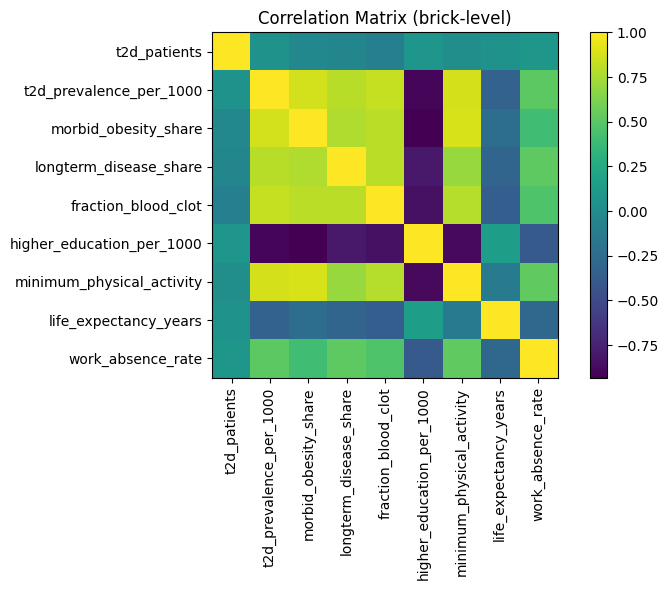


Correlation with T2D prevalence per 1000 (sorted):
t2d_prevalence_per_1000      1.000000
minimum_physical_activity    0.872541
morbid_obesity_share         0.864901
fraction_blood_clot          0.828753
longterm_disease_share       0.794515
work_absence_rate            0.511937
t2d_patients                 0.050995
life_expectancy_years       -0.320282
higher_education_per_1000   -0.894309
Name: t2d_prevalence_per_1000, dtype: float64


In [1836]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(9,6))
im = plt.imshow(corr, interpolation="nearest")
plt.title("Correlation Matrix (brick-level)")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(np.arange(len(numeric_cols)), labels=numeric_cols, rotation=90)
plt.yticks(np.arange(len(numeric_cols)), labels=numeric_cols)
plt.tight_layout()
plt.show()

# Also print correlations with our main KPI (prevalence)
if "t2d_prevalence_per_1000" in corr.columns:
    print("\nCorrelation with T2D prevalence per 1000 (sorted):")
    print(corr["t2d_prevalence_per_1000"].sort_values(ascending=False))

In [1837]:
# R correlation matrix (for Factor Analysis)

satData = df
numeric_data = satData.select_dtypes(include=["number"])
satMatrix = numeric_data.corr()
satMatrix_rounded = satMatrix.round(2)
print(satMatrix_rounded)

                           brick_id  t2d_patients  t2d_prevalence_per_1000  \
brick_id                       1.00         -0.18                     0.16   
t2d_patients                  -0.18          1.00                     0.05   
t2d_prevalence_per_1000        0.16          0.05                     1.00   
morbid_obesity_share           0.42         -0.03                     0.86   
longterm_disease_share         0.27         -0.04                     0.79   
fraction_blood_clot            0.29         -0.09                     0.83   
higher_education_per_1000     -0.46          0.08                    -0.89   
minimum_physical_activity      0.19          0.02                     0.87   
life_expectancy_years          0.24          0.05                    -0.32   
work_absence_rate             -0.26          0.09                     0.51   

                           morbid_obesity_share  longterm_disease_share  \
brick_id                                   0.42                   

In [1838]:
# finding the factors that has the highest correlations

# Correlation matrix
corr_matrix = numeric_data.corr().round(2)

# Convert to long format (pairs of variables)
corr_pairs = corr_matrix.unstack()

# Remove self-correlations (always = 1.0)
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]

# Drop duplicate pairs (A,B) vs (B,A)
corr_pairs = corr_pairs.drop_duplicates().sort_values(ascending=False)

# Show top 10 highest correlations
print(corr_pairs.head(10))

morbid_obesity_share       minimum_physical_activity    0.88
t2d_prevalence_per_1000    minimum_physical_activity    0.87
                           morbid_obesity_share         0.86
                           fraction_blood_clot          0.83
morbid_obesity_share       fraction_blood_clot          0.80
t2d_prevalence_per_1000    longterm_disease_share       0.79
fraction_blood_clot        minimum_physical_activity    0.78
morbid_obesity_share       longterm_disease_share       0.77
longterm_disease_share     minimum_physical_activity    0.70
minimum_physical_activity  work_absence_rate            0.53
dtype: float64


In [1839]:
# KMO Test - requires only numeric columns
numeric_cols = [c for c in df.columns if c not in ["brick_id","brick_name"]]
df_clean = df[numeric_cols].dropna()

kmo_all, kmo_model = calculate_kmo(df_clean)
kmo_model

0.8370284776778556

In [1840]:
df_clean.head()

,t2d_patients,t2d_prevalence_per_1000,morbid_obesity_share,longterm_disease_share,fraction_blood_clot,higher_education_per_1000,minimum_physical_activity,life_expectancy_years,work_absence_rate
0,2248.978472,68.055997,0.175500,0.406500,0.0205,182.632048,0.302000,77.190500,6.286500
1,6136.772115,39.783553,0.130333,0.326667,0.0090,420.156850,0.243333,79.967667,5.747333
2,3019.148357,34.194651,0.107500,0.305000,0.0075,501.522310,0.221500,79.283000,5.499500
3,3387.602593,32.872750,0.100000,0.307500,0.0080,480.858397,0.225000,80.050000,5.580000
4,3574.931136,33.962865,0.104000,0.306000,0.0080,496.504346,0.223000,79.645500,5.537500


c:\Users\johan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Eigenvalues:
[5.546 1.059 1.03  0.637 0.304 0.182 0.118 0.082 0.042]

Kaiser suggested factors (>1): 3


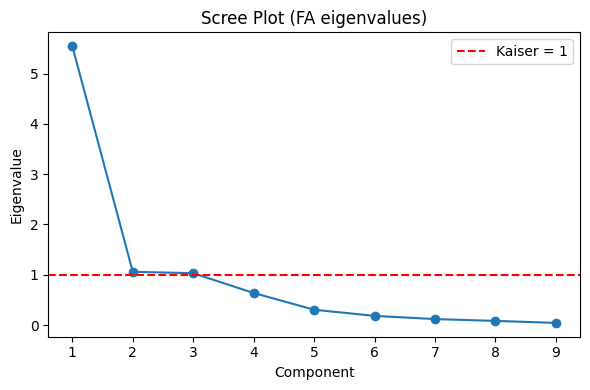

Defaulting to n_factors = 3


In [1841]:
# === Determine number of factors (eigenvalues + scree) ===
try:
    from factor_analyzer import FactorAnalyzer
except ImportError:  # fallback for some installs
    from factor_analyzer.factor_analyzer import FactorAnalyzer

fa_tmp = FactorAnalyzer(n_factors=df_clean.shape[1], rotation=None, method='principal')
fa_tmp.fit(df_clean)
ev, v = fa_tmp.get_eigenvalues()

print("Eigenvalues:")
print(np.round(ev, 3))

# Kaiser criterion (eigenvalue > 1)
kaiser_count = int(np.sum(ev > 1))
print(f"\nKaiser suggested factors (>1): {kaiser_count}")

# Scree plot
plt.figure(figsize=(6,4))
plt.plot(range(1, len(ev)+1), ev, marker='o')
plt.axhline(1, color='red', linestyle='--', label='Kaiser = 1')
plt.title('Scree Plot (FA eigenvalues)')
plt.xlabel('Component')
plt.ylabel('Eigenvalue')
plt.xticks(range(1, len(ev)+1))
plt.legend()
plt.tight_layout()
plt.show()

# Pick a default n_factors using Kaiser; you can override based on scree/interpretability
n_factors = max(1, kaiser_count)
print(f"Defaulting to n_factors = {n_factors}")

In [1842]:
# === Factor Analysis (varimax) and loadings ===
# If you want to override automatically chosen n_factors, set it here, e.g., n_factors = 3
from pprint import pprint

fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax', method='principal')
fa.fit(df_clean)

# Loadings
loadings = pd.DataFrame(
    fa.loadings_,
    index=df_clean.columns,
    columns=[f"Factor{i+1}" for i in range(n_factors)]
)

print("Factor loadings (rounded):")
print(loadings.round(3).sort_index())

# Communalities and uniqueness
communalities = pd.Series(fa.get_communalities(), index=df_clean.columns, name='communality')
uniqueness = pd.Series(fa.get_uniquenesses(), index=df_clean.columns, name='uniqueness')
print("\nCommunalities (variance explained by factors):")
print(communalities.round(3).sort_values(ascending=False))
print("\nUniqueness (variance not explained):")
print(uniqueness.round(3).sort_values(ascending=True))

Factor loadings (rounded):
                           Factor1  Factor2  Factor3
fraction_blood_clot          0.866   -0.085    0.293
higher_education_per_1000   -0.973    0.068   -0.023
life_expectancy_years       -0.086    0.098   -0.933
longterm_disease_share       0.831   -0.011    0.295
minimum_physical_activity    0.935    0.094    0.047
morbid_obesity_share         0.938   -0.016    0.100
t2d_patients                -0.043    0.965   -0.029
t2d_prevalence_per_1000      0.915    0.091    0.238
work_absence_rate            0.462    0.303    0.507

Communalities (variance explained by factors):
higher_education_per_1000    0.951
t2d_patients                 0.933
t2d_prevalence_per_1000      0.902
morbid_obesity_share         0.890
life_expectancy_years        0.888
minimum_physical_activity    0.885
fraction_blood_clot          0.844
longterm_disease_share       0.778
work_absence_rate            0.563
Name: communality, dtype: float64

Uniqueness (variance not explained):
higher_e

c:\Users\johan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [1843]:
# === Factor scores and relation to outcome ===
# Compute factor scores
scores = pd.DataFrame(
    fa.transform(df_clean),
    index=df_clean.index,
    columns=[f"Factor{i+1}" for i in range(n_factors)]
)

# Attach brick metadata and preview
scores_with_meta = pd.concat([
    df.loc[scores.index, ["brick_id", "brick_name"]].reset_index(drop=True),
    scores.reset_index(drop=True)
], axis=1)

print("Scores preview:")
display(scores_with_meta.head())

# Correlate factor scores with T2D prevalence (if available)
if "t2d_prevalence_per_1000" in df.columns:
    y = df.loc[scores.index, "t2d_prevalence_per_1000"].reset_index(drop=True)
    corr_with_outcome = pd.concat([scores.reset_index(drop=True), y.rename("t2d_prevalence_per_1000")], axis=1).corr()["t2d_prevalence_per_1000"].drop("t2d_prevalence_per_1000")
    print("\nCorrelation of factors with T2D prevalence per 1000:")
    print(corr_with_outcome.sort_values(ascending=False).round(3))

# Persist scores for use in regression analysis
scores_with_meta.to_csv("../files/factor_scores.csv", index=False)
print(f"\n✓ Factor scores saved to: ../files/factor_scores.csv")

Scores preview:


c:\Users\johan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,brick_id,brick_name,Factor1,Factor2,Factor3
0,101,Bornholm,0.440208,-1.421423,4.087883
1,102,Amager,-1.697972,1.433589,0.929766
2,103,Noerrebro/City,-2.510865,-0.951002,1.487976
3,104,Vesterbro/Christianshavn,-2.322488,-0.567296,0.858742
4,105,Frederiksberg,-2.421395,-0.508538,1.201546



Correlation of factors with T2D prevalence per 1000:
Factor1    0.915
Factor3    0.238
Factor2    0.091
Name: t2d_prevalence_per_1000, dtype: float64

✓ Factor scores saved to: ../files/factor_scores.csv


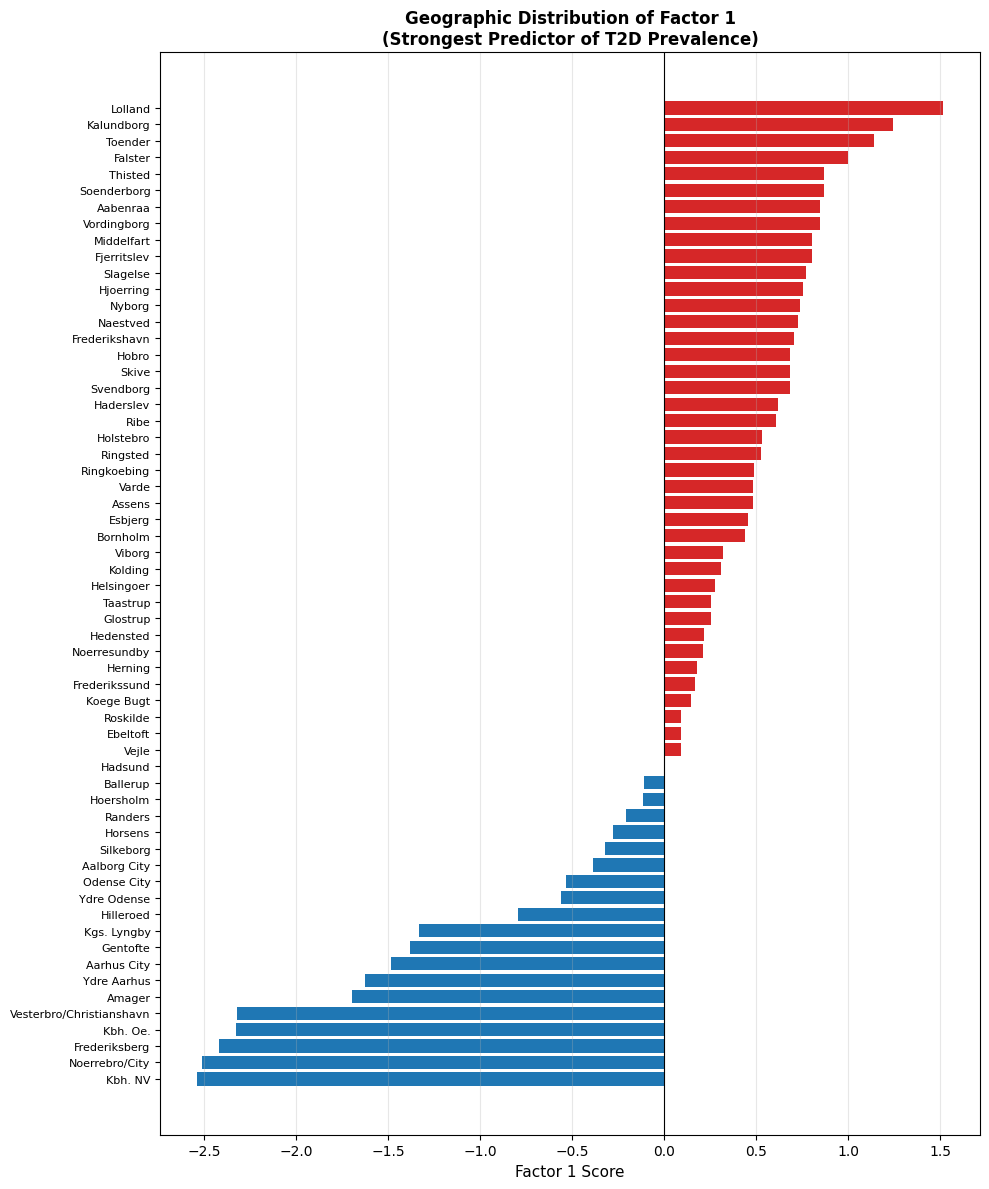


Top 10 areas with HIGHEST Factor 1 scores (highest T2D risk):
 brick_name  Factor1
Fjerritslev 0.805505
 Middelfart 0.806294
Vordingborg 0.845348
   Aabenraa 0.848346
Soenderborg 0.867567
    Thisted 0.868879
    Falster 0.997174
    Toender 1.139800
 Kalundborg 1.243409
    Lolland 1.514691


Top 10 areas with LOWEST Factor 1 scores (lowest T2D risk):
              brick_name   Factor1
                 Kbh. NV -2.536409
          Noerrebro/City -2.510865
           Frederiksberg -2.421395
                Kbh. Oe. -2.327751
Vesterbro/Christianshavn -2.322488
                  Amager -1.697972
             Ydre Aarhus -1.628380
             Aarhus City -1.483424
                Gentofte -1.380207
             Kgs. Lyngby -1.331767


In [1844]:
# === Visualize Factor 1 geographic distribution ===
# Sort by Factor 1 score and create horizontal bar chart
factor1_sorted = scores_with_meta.sort_values('Factor1', ascending=True)

plt.figure(figsize=(10, 12))
plt.barh(range(len(factor1_sorted)), factor1_sorted['Factor1'], 
         color=['#d62728' if x > 0 else '#1f77b4' for x in factor1_sorted['Factor1']])
plt.yticks(range(len(factor1_sorted)), factor1_sorted['brick_name'], fontsize=8)
plt.xlabel('Factor 1 Score', fontsize=11)
plt.title('Geographic Distribution of Factor 1\n(Strongest Predictor of T2D Prevalence)', fontsize=12, fontweight='bold')
plt.axvline(0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Show top 10 and bottom 10
print("\nTop 10 areas with HIGHEST Factor 1 scores (highest T2D risk):")
print(factor1_sorted[['brick_name', 'Factor1']].tail(10).to_string(index=False))

print("\n\nTop 10 areas with LOWEST Factor 1 scores (lowest T2D risk):")
print(factor1_sorted[['brick_name', 'Factor1']].head(10).to_string(index=False))

In [1845]:
# Display Factor 1 data
factor1_sorted.head()

,brick_id,brick_name,Factor1,Factor2,Factor3
6,107,Kbh. NV,-2.536409,-0.344208,1.444335
2,103,Noerrebro/City,-2.510865,-0.951002,1.487976
4,105,Frederiksberg,-2.421395,-0.508538,1.201546
7,108,Kbh. Oe.,-2.327751,-0.457462,-0.019235
3,104,Vesterbro/Christianshavn,-2.322488,-0.567296,0.858742


In [1846]:
# === Add GLP-1 sales volume by brick and merge into df ===
# Load sales file (semicolon; Danish decimals)
sales = pd.read_csv("../files/Sales-Bricks.csv", sep=";", encoding="latin-1")

# Normalize column names
sales.columns = [c.strip().upper() for c in sales.columns]

# Keep only GLP-1 market rows
sales_glp = sales[sales["MARKET"].str.strip().str.upper() == "GLP-1"].copy()

# Ensure BRICK_CODE numeric
sales_glp["BRICK_CODE"] = pd.to_numeric(sales_glp["BRICK_CODE"], errors="coerce").astype("Int64")

# Clean VOLUME column (remove spaces/thousands and convert decimal comma -> dot)
if "VOLUME" in sales_glp.columns:
    sales_glp["VOLUME"] = (
        sales_glp["VOLUME"]
        .astype(str)
        .str.replace(" ", "", regex=False)
        .str.replace(".", "", regex=False)   # remove thousands dot if present
        .str.replace(",", ".", regex=False)  # decimal comma -> dot
    )
    sales_glp["VOLUME"] = pd.to_numeric(sales_glp["VOLUME"], errors="coerce")
else:
    sales_glp["VOLUME"] = pd.NA

# Clean VALUE column if present (same normalization)
if "VALUE" in sales_glp.columns:
    sales_glp["VALUE"] = (
        sales_glp["VALUE"]
        .astype(str)
        .str.replace(" ", "", regex=False)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
        .str.replace(r"[^\d\.-]", "", regex=True)  # drop any stray currency symbols
    )
    sales_glp["VALUE"] = pd.to_numeric(sales_glp["VALUE"], errors="coerce")
else:
    sales_glp["VALUE"] = pd.NA

# Aggregate total GLP-1 volume and value per brick (sum across months)
sales_agg = sales_glp.groupby("BRICK_CODE", dropna=True).agg(
    sales_glp_volume_total=("VOLUME", "sum"),
    sales_glp_value_total=("VALUE", "sum")
).reset_index()

# Compute volume share of total GLP-1 volume (per brick)
total_volume = sales_agg["sales_glp_volume_total"].sum()
if pd.notna(total_volume) and total_volume > 0:
    sales_agg["sales_glp_volume_share"] = sales_agg["sales_glp_volume_total"] / total_volume
else:
    sales_agg["sales_glp_volume_share"] = pd.NA

# Prepare df.brick_id numeric for safe merge
df["brick_id"] = pd.to_numeric(df["brick_id"], errors="coerce").astype("Int64")

# Merge: keep only bricks present in both (drop rows without match)
before_n = df.shape[0]
df = df.merge(sales_agg, left_on="brick_id", right_on="BRICK_CODE", how="inner")
df = df.drop(columns=["BRICK_CODE"])  # drop duplicate key column from sales
after_n = df.shape[0]

print(f"Rows before merge: {before_n}  —  after inner merge (kept matches): {after_n}")
print("Added columns: 'sales_glp_volume_total', 'sales_glp_value_total', 'sales_glp_volume_share'")

Rows before merge: 60  —  after inner merge (kept matches): 60
Added columns: 'sales_glp_volume_total', 'sales_glp_value_total', 'sales_glp_volume_share'


In [1847]:
df.head()

,brick_id,brick_name,t2d_patients,t2d_prevalence_per_1000,morbid_obesity_share,longterm_disease_share,fraction_blood_clot,higher_education_per_1000,minimum_physical_activity,life_expectancy_years,work_absence_rate,sales_glp_volume_total,sales_glp_value_total,sales_glp_volume_share
0,101,Bornholm,2248.978472,68.055997,0.175500,0.406500,0.0205,182.632048,0.302000,77.190500,6.286500,4832,4206135.32,0.012685
1,102,Amager,6136.772115,39.783553,0.130333,0.326667,0.0090,420.156850,0.243333,79.967667,5.747333,10647,9227040.07,0.027951
2,103,Noerrebro/City,3019.148357,34.194651,0.107500,0.305000,0.0075,501.522310,0.221500,79.283000,5.499500,3048,2881603.88,0.008002
3,104,Vesterbro/Christianshavn,3387.602593,32.872750,0.100000,0.307500,0.0080,480.858397,0.225000,80.050000,5.580000,4728,4213623.21,0.012412
4,105,Frederiksberg,3574.931136,33.962865,0.104000,0.306000,0.0080,496.504346,0.223000,79.645500,5.537500,5592,5133362.55,0.014680


In [1848]:
# === Merge factor scores back into main df by brick_id ===
# scores_with_meta already contains brick_id and Factor1, Factor2, Factor3 (etc.)
# Merge into df using left join to keep all df rows, fill NaN for non-matches

df = df.merge(scores_with_meta[["brick_id"] + [col for col in scores_with_meta.columns if col.startswith("Factor")]], 
              on="brick_id", 
              how="left")

print(f"After merging factors into df: df.shape = {df.shape}")
print(f"Columns now include: {[col for col in df.columns if col.startswith('Factor')]}")

# Show sample
print("\nSample of df with factors:")
display(df[["brick_id", "brick_name", "sales_glp_volume_total"] + [col for col in df.columns if col.startswith("Factor")]].head(10))

# Save full enriched dataset
df.to_csv("../files/merged_with_factors.csv", index=False)
print(f"\n✓ Full dataset with factors saved to: ../files/merged_with_factors.csv")

After merging factors into df: df.shape = (60, 17)
Columns now include: ['Factor1', 'Factor2', 'Factor3']

Sample of df with factors:


,brick_id,brick_name,sales_glp_volume_total,Factor1,Factor2,Factor3
0,101,Bornholm,4832,0.440208,-1.421423,4.087883
1,102,Amager,10647,-1.697972,1.433589,0.929766
2,103,Noerrebro/City,3048,-2.510865,-0.951002,1.487976
3,104,Vesterbro/Christianshavn,4728,-2.322488,-0.567296,0.858742
4,105,Frederiksberg,5592,-2.421395,-0.508538,1.201546
5,106,Glostrup,13947,0.254226,2.750593,0.885885
6,107,Kbh. NV,5123,-2.536409,-0.344208,1.444335
7,108,Kbh. Oe.,2928,-2.327751,-0.457462,-0.019235
8,109,Gentofte,4712,-1.380207,-0.604704,-1.145976
9,110,Kgs. Lyngby,4492,-1.331767,-0.110714,-1.185523



✓ Full dataset with factors saved to: ../files/merged_with_factors.csv


In [1849]:
df.head()

,brick_id,brick_name,t2d_patients,t2d_prevalence_per_1000,morbid_obesity_share,longterm_disease_share,fraction_blood_clot,higher_education_per_1000,minimum_physical_activity,life_expectancy_years,work_absence_rate,sales_glp_volume_total,sales_glp_value_total,sales_glp_volume_share,Factor1,Factor2,Factor3
0,101,Bornholm,2248.978472,68.055997,0.175500,0.406500,0.0205,182.632048,0.302000,77.190500,6.286500,4832,4206135.32,0.012685,0.440208,-1.421423,4.087883
1,102,Amager,6136.772115,39.783553,0.130333,0.326667,0.0090,420.156850,0.243333,79.967667,5.747333,10647,9227040.07,0.027951,-1.697972,1.433589,0.929766
2,103,Noerrebro/City,3019.148357,34.194651,0.107500,0.305000,0.0075,501.522310,0.221500,79.283000,5.499500,3048,2881603.88,0.008002,-2.510865,-0.951002,1.487976
3,104,Vesterbro/Christianshavn,3387.602593,32.872750,0.100000,0.307500,0.0080,480.858397,0.225000,80.050000,5.580000,4728,4213623.21,0.012412,-2.322488,-0.567296,0.858742
4,105,Frederiksberg,3574.931136,33.962865,0.104000,0.306000,0.0080,496.504346,0.223000,79.645500,5.537500,5592,5133362.55,0.014680,-2.421395,-0.508538,1.201546


## Choose the outcome(s)
At brick level, define:

Primary outcome:
- glp1_sales_value_per_1000 = (total GLP-1 sales value in brick) / population * 1000
- This controls for different brick sizes, so you model intensity rather than just big vs small regions.

Optionally log-transform if very skewed:

- log_glp1_sales = log(glp1_sales_value_per_1000)

This matches the continuous-outcome OLS setup from the slides.

In [1850]:

# Map population (from t2d.brick_nr) into df and compute GLP-1 sales value per 1000 people

# prefer the cleaned population column if present, otherwise try fallbacks
# tager population fra t2d arket som er total population
if "population_t2d" in t2d.columns:
    t2d_population = t2d.set_index("brick_nr")["population_t2d"]
elif "population" in t2d.columns:
    t2d_population = t2d.set_index("brick_nr")["population"]


t2d_population = pd.to_numeric(t2d_population, errors="coerce").astype(float)

# ensure sales value column is numeric
df["sales_glp_value_total"] = pd.to_numeric(df.get("sales_glp_value_total", pd.Series(dtype=float)), errors="coerce")

# map population into df and compute per-1000 metric
df["population"] = df["brick_id"].map(t2d_population)
df["glp1_sales_value_per_1"] = np.where(
    (df["population"].notna()) & (df["population"] > 0),
    (df["sales_glp_value_total"] / df["population"])* 1,
    pd.NA
)

# quick check
print("Created column: glp1_sales_value_per_1  —  missing:", df["glp1_sales_value_per_1"].isna().sum())
df[["brick_id", "brick_name", "sales_glp_value_total", "population", "glp1_sales_value_per_1"]].head()




Created column: glp1_sales_value_per_1  —  missing: 0


,brick_id,brick_name,sales_glp_value_total,population,glp1_sales_value_per_1
0,101,Bornholm,4206135.32,33046.0,127.281224
1,102,Amager,9227040.07,154254.0,59.817185
2,103,Noerrebro/City,2881603.88,88293.0,32.636833
3,104,Vesterbro/Christianshavn,4213623.21,103052.0,40.888321
4,105,Frederiksberg,5133362.55,105260.0,48.768407


In [1851]:
# map population into df and compute per-1000 metric
df["population"] = df["brick_id"].map(t2d_population)
df["glp1_sales_volume_per_1"] = np.where(
    (df["population"].notna()) & (df["population"] > 0),
    (df["sales_glp_volume_total"] / df["population"])* 1,
    pd.NA
)

# quick check
print("Created column: glp1_sales_volume_per_1  —  missing:", df["glp1_sales_volume_per_1"].isna().sum())
df[["brick_id", "brick_name", "sales_glp_volume_total", "population", "glp1_sales_volume_per_1"]].head()

Created column: glp1_sales_volume_per_1  —  missing: 0


,brick_id,brick_name,sales_glp_volume_total,population,glp1_sales_volume_per_1
0,101,Bornholm,4832,33046.0,0.14622
1,102,Amager,10647,154254.0,0.069023
2,103,Noerrebro/City,3048,88293.0,0.034521
3,104,Vesterbro/Christianshavn,4728,103052.0,0.04588
4,105,Frederiksberg,5592,105260.0,0.053126


In [1852]:
# Calculate unit price (DKK per unit). If volume is missing or zero, set as NA.
df["glp1_unit_price"] = np.where(
    (df["sales_glp_volume_total"].notna()) & (df["sales_glp_volume_total"] > 0),
    df["sales_glp_value_total"] / df["sales_glp_volume_total"],
    pd.NA
)

# Optional: inspect results
display(df[["brick_id", "brick_name", "sales_glp_volume_total", "sales_glp_value_total", "glp1_unit_price"]].head(10))

,brick_id,brick_name,sales_glp_volume_total,sales_glp_value_total,glp1_unit_price
0,101,Bornholm,4832,4206135.32,870.475025
1,102,Amager,10647,9227040.07,866.632861
2,103,Noerrebro/City,3048,2881603.88,945.408097
3,104,Vesterbro/Christianshavn,4728,4213623.21,891.206263
4,105,Frederiksberg,5592,5133362.55,917.983289
5,106,Glostrup,13947,12412591.16,889.982875
6,107,Kbh. NV,5123,4596125.36,897.155058
7,108,Kbh. Oe.,2928,2594955.56,886.255314
8,109,Gentofte,4712,4209053.25,893.262574
9,110,Kgs. Lyngby,4492,4018170.56,894.517044


In [1853]:
df.head()

,brick_id,brick_name,t2d_patients,t2d_prevalence_per_1000,morbid_obesity_share,longterm_disease_share,fraction_blood_clot,higher_education_per_1000,minimum_physical_activity,life_expectancy_years,...,sales_glp_volume_total,sales_glp_value_total,sales_glp_volume_share,Factor1,Factor2,Factor3,population,glp1_sales_value_per_1,glp1_sales_volume_per_1,glp1_unit_price
0,101,Bornholm,2248.978472,68.055997,0.175500,0.406500,0.0205,182.632048,0.302000,77.190500,...,4832,4206135.32,0.012685,0.440208,-1.421423,4.087883,33046.0,127.281224,0.14622,870.475025
1,102,Amager,6136.772115,39.783553,0.130333,0.326667,0.0090,420.156850,0.243333,79.967667,...,10647,9227040.07,0.027951,-1.697972,1.433589,0.929766,154254.0,59.817185,0.069023,866.632861
2,103,Noerrebro/City,3019.148357,34.194651,0.107500,0.305000,0.0075,501.522310,0.221500,79.283000,...,3048,2881603.88,0.008002,-2.510865,-0.951002,1.487976,88293.0,32.636833,0.034521,945.408097
3,104,Vesterbro/Christianshavn,3387.602593,32.872750,0.100000,0.307500,0.0080,480.858397,0.225000,80.050000,...,4728,4213623.21,0.012412,-2.322488,-0.567296,0.858742,103052.0,40.888321,0.04588,891.206263
4,105,Frederiksberg,3574.931136,33.962865,0.104000,0.306000,0.0080,496.504346,0.223000,79.645500,...,5592,5133362.55,0.014680,-2.421395,-0.508538,1.201546,105260.0,48.768407,0.053126,917.983289


## convert columns from object to numeric to check log-transformation

In [1854]:
df['glp1_sales_volume_per_1'] = pd.to_numeric(df['glp1_sales_volume_per_1'], errors='coerce')
df['glp1_sales_volume_per_1'].dtypes

dtype('float64')

In [1855]:
# Convert to numeric (invalid parsing will be set as NaN)
df['glp1_sales_value_per_1'] = pd.to_numeric(df['glp1_sales_value_per_1'], errors='coerce')
df['glp1_sales_value_per_1'].dtypes

dtype('float64')

### To decide whether your GLP-1 sales intensity variable is “very skewed” and should be log-transformed, you can follow the exact workflow used in your regression lecture slides (EDA → check distributions → consider transformations).

## Check skewness numerically

A rule of thumb:

|skew| < 1 → fine

|skew| 1–2 → moderately skewed

|skew| > 2 → highly skewed, log-transform recommended

In [1856]:
df['glp1_sales_value_per_1'].skew()

0.3351482728432968

In [1857]:
df['glp1_sales_volume_per_1'].skew()

0.24976985444629393

## Visualize distribution (histogram + KDE)

This is what your slides emphasize (slide 17–18).

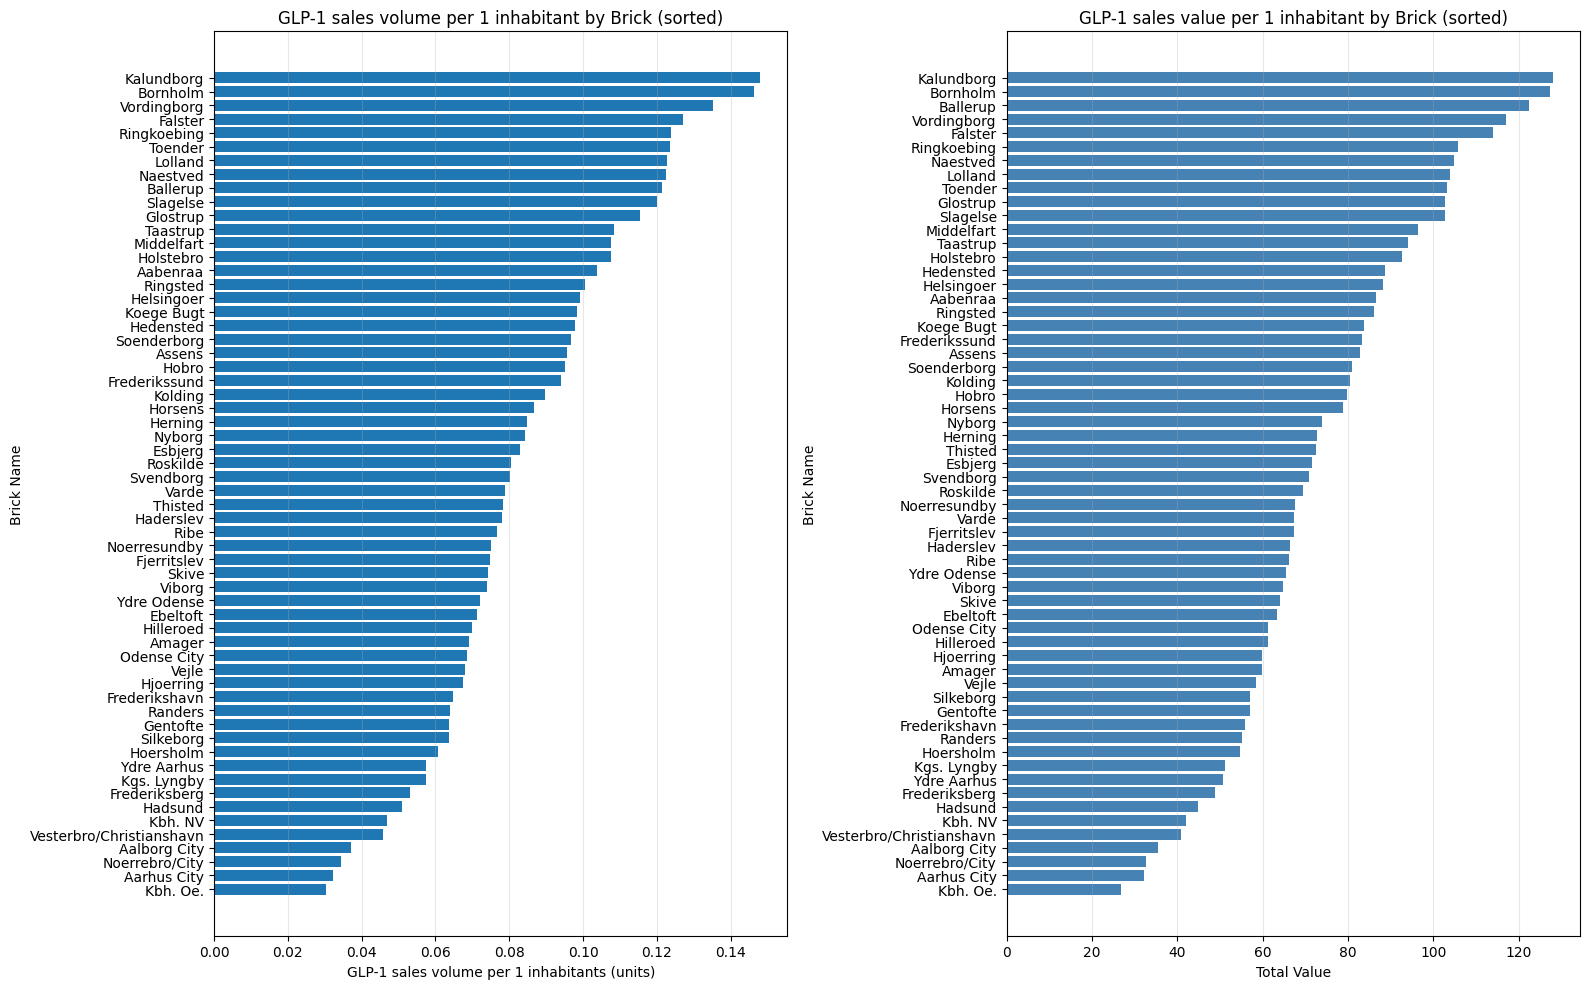

In [1858]:
# Plot GLP-1 sales volume per 1 by brick (sorted)
# Visualize ALL bricks by value (sorted)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))

plot_df_vol = df[["brick_name", "glp1_sales_volume_per_1"]].dropna().sort_values(
    "glp1_sales_volume_per_1", ascending=True
)
plot_df_val = df[["brick_name", "glp1_sales_value_per_1"]].dropna().sort_values(
    "glp1_sales_value_per_1", ascending=True
)


ax1.barh(plot_df_vol["brick_name"].astype(str), plot_df_vol["glp1_sales_volume_per_1"], color="tab:blue")
ax1.set_xlabel("GLP-1 sales volume per 1 inhabitants (units)")
ax1.set_ylabel("Brick Name")
ax1.set_title("GLP-1 sales volume per 1 inhabitant by Brick (sorted)")
ax1.grid(axis="x", alpha=0.3)

ax2.barh(plot_df_val["brick_name"].astype(str), plot_df_val["glp1_sales_value_per_1"], color="steelblue")
ax2.set_xlabel("Total Value")
ax2.set_ylabel("Brick Name")
ax2.set_title("GLP-1 sales value per 1 inhabitant by Brick (sorted)")
ax2.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

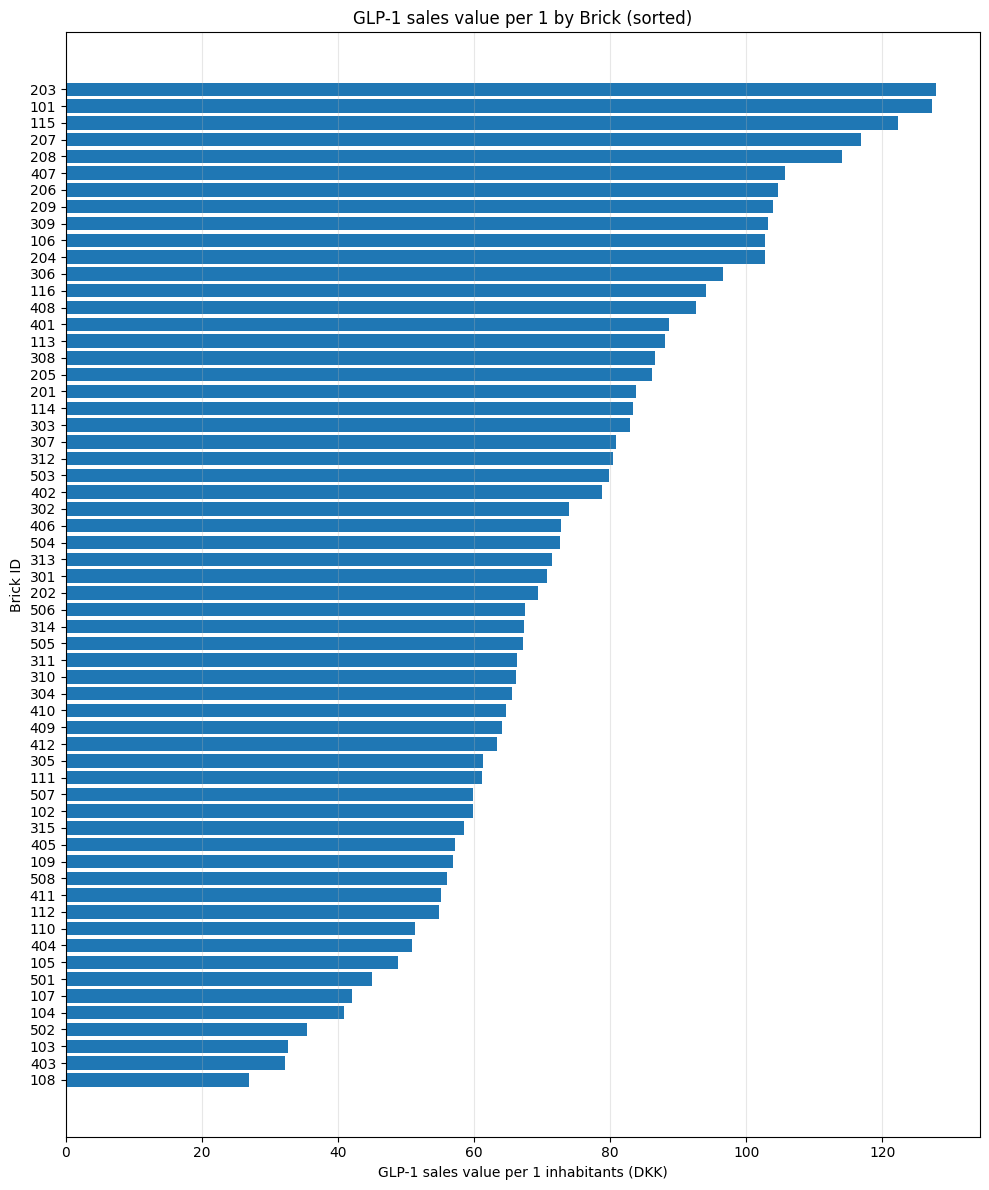

In [1859]:
# Plot GLP-1 sales value per 1000 by brick (sorted)
plot_df = df[["brick_id", "glp1_sales_value_per_1"]].dropna().sort_values(
    "glp1_sales_value_per_1", ascending=True
)

plt.figure(figsize=(10, 12))
plt.barh(plot_df["brick_id"].astype(str), plot_df["glp1_sales_value_per_1"], color="tab:blue")
plt.xlabel("GLP-1 sales value per 1 inhabitants (DKK)")
plt.ylabel("Brick ID")
plt.title("GLP-1 sales value per 1 by Brick (sorted)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


In [1860]:
both = df[["brick_id","brick_name","glp1_sales_value_per_1","glp1_sales_volume_per_1"]]
both = both.sort_values("glp1_sales_value_per_1", ascending=False).head(30)

In [1861]:
# prepare the two tables (sorted as you like)
tbl_value = (df[["brick_id","brick_name","glp1_sales_value_per_1"]]
             .dropna()
             .sort_values("glp1_sales_value_per_1", ascending=False)
             .head(n)
             .reset_index(drop=True))

tbl_volume = (df[["brick_id","brick_name","glp1_sales_volume_per_1"]]
              .dropna()
              .sort_values("glp1_sales_volume_per_1", ascending=False)
              .head(n)
              .reset_index(drop=True))



In [1862]:
from pathlib import Path

out_dir = Path("../files")
out_dir.mkdir(parents=True, exist_ok=True)

out_path = out_dir / "johan_super__merged_final.csv"   # stable filename (no datetime)
df.to_csv(out_path, index=False, encoding="latin-1", float_format="%.6f", na_rep="")

print(f"✓ Exported df to: {out_path}")
print(f"Shape: {df.shape}")
display(df.head())

✓ Exported df to: ..\files\johan_super__merged_final.csv
Shape: (60, 21)


,brick_id,brick_name,t2d_patients,t2d_prevalence_per_1000,morbid_obesity_share,longterm_disease_share,fraction_blood_clot,higher_education_per_1000,minimum_physical_activity,life_expectancy_years,...,sales_glp_volume_total,sales_glp_value_total,sales_glp_volume_share,Factor1,Factor2,Factor3,population,glp1_sales_value_per_1,glp1_sales_volume_per_1,glp1_unit_price
0,101,Bornholm,2248.978472,68.055997,0.175500,0.406500,0.0205,182.632048,0.302000,77.190500,...,4832,4206135.32,0.012685,0.440208,-1.421423,4.087883,33046.0,127.281224,0.146220,870.475025
1,102,Amager,6136.772115,39.783553,0.130333,0.326667,0.0090,420.156850,0.243333,79.967667,...,10647,9227040.07,0.027951,-1.697972,1.433589,0.929766,154254.0,59.817185,0.069023,866.632861
2,103,Noerrebro/City,3019.148357,34.194651,0.107500,0.305000,0.0075,501.522310,0.221500,79.283000,...,3048,2881603.88,0.008002,-2.510865,-0.951002,1.487976,88293.0,32.636833,0.034521,945.408097
3,104,Vesterbro/Christianshavn,3387.602593,32.872750,0.100000,0.307500,0.0080,480.858397,0.225000,80.050000,...,4728,4213623.21,0.012412,-2.322488,-0.567296,0.858742,103052.0,40.888321,0.045880,891.206263
4,105,Frederiksberg,3574.931136,33.962865,0.104000,0.306000,0.0080,496.504346,0.223000,79.645500,...,5592,5133362.55,0.014680,-2.421395,-0.508538,1.201546,105260.0,48.768407,0.053126,917.983289


In [1863]:
df

,brick_id,brick_name,t2d_patients,t2d_prevalence_per_1000,morbid_obesity_share,longterm_disease_share,fraction_blood_clot,higher_education_per_1000,minimum_physical_activity,life_expectancy_years,...,sales_glp_volume_total,sales_glp_value_total,sales_glp_volume_share,Factor1,Factor2,Factor3,population,glp1_sales_value_per_1,glp1_sales_volume_per_1,glp1_unit_price
0,101,Bornholm,2248.978472,68.055997,0.175500,0.406500,0.020500,182.632048,0.302000,77.190500,...,4832,4206135.32,0.012685,0.440208,-1.421423,4.087883,33046.0,127.281224,0.146220,870.475025
1,102,Amager,6136.772115,39.783553,0.130333,0.326667,0.009000,420.156850,0.243333,79.967667,...,10647,9227040.07,0.027951,-1.697972,1.433589,0.929766,154254.0,59.817185,0.069023,866.632861
2,103,Noerrebro/City,3019.148357,34.194651,0.107500,0.305000,0.007500,501.522310,0.221500,79.283000,...,3048,2881603.88,0.008002,-2.510865,-0.951002,1.487976,88293.0,32.636833,0.034521,945.408097
3,104,Vesterbro/Christianshavn,3387.602593,32.872750,0.100000,0.307500,0.008000,480.858397,0.225000,80.050000,...,4728,4213623.21,0.012412,-2.322488,-0.567296,0.858742,103052.0,40.888321,0.045880,891.206263
4,105,Frederiksberg,3574.931136,33.962865,0.104000,0.306000,0.008000,496.504346,0.223000,79.645500,...,5592,5133362.55,0.014680,-2.421395,-0.508538,1.201546,105260.0,48.768407,0.053126,917.983289
5,106,Glostrup,7612.328605,63.024313,0.184000,0.378400,0.013600,266.845511,0.312800,80.101800,...,13947,12412591.16,0.036614,0.254226,2.750593,0.885885,120784.0,102.766850,0.115471,889.982875
6,107,Kbh. NV,3844.163863,35.167541,0.106500,0.305000,0.007500,517.512247,0.221500,79.365000,...,5123,4596125.36,0.013449,-2.536409,-0.344208,1.444335,109310.0,42.046705,0.046867,897.155058
7,108,Kbh. Oe.,3294.066993,34.150627,0.096500,0.310500,0.005500,500.412473,0.220000,80.978500,...,2928,2594955.56,0.007687,-2.327751,-0.457462,-0.019235,96457.0,26.902719,0.030355,886.255314
8,109,Gentofte,3025.262377,40.912332,0.110667,0.327667,0.007667,422.656664,0.250000,81.986667,...,4712,4209053.25,0.012370,-1.380207,-0.604704,-1.145976,73945.0,56.921404,0.063723,893.262574
9,110,Kgs. Lyngby,3039.645929,38.796727,0.094500,0.332000,0.008500,445.921077,0.253600,82.726400,...,4492,4018170.56,0.011793,-1.331767,-0.110714,-1.185523,78348.0,51.286192,0.057334,894.517044


In [1864]:
tbl_value, tbl_volume

(    brick_id     brick_name  glp1_sales_value_per_1
 0        203     Kalundborg              127.950476
 1        101       Bornholm              127.281224
 2        115       Ballerup              122.345582
 3        207    Vordingborg              116.923456
 4        208        Falster              114.014288
 5        407    Ringkoebing              105.751806
 6        206       Naestved              104.714489
 7        209        Lolland              103.963574
 8        309        Toender              103.168356
 9        106       Glostrup              102.766850
 10       204       Slagelse              102.694403
 11       306     Middelfart               96.508173
 12       116       Taastrup               94.093212
 13       408      Holstebro               92.577875
 14       401      Hedensted               88.592456
 15       113     Helsingoer               88.110541
 16       308       Aabenraa               86.645961
 17       205       Ringsted               86.

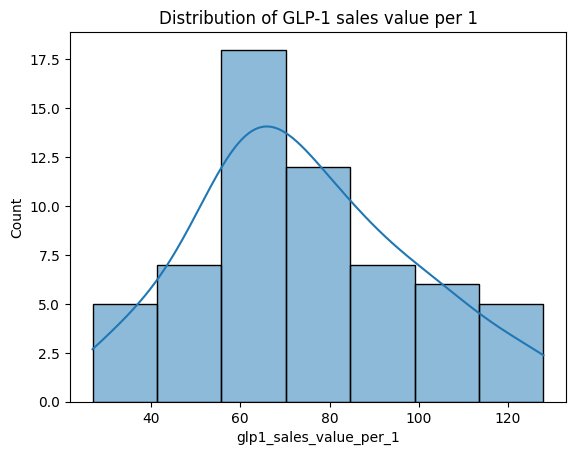

In [1865]:
sns.histplot(df['glp1_sales_value_per_1'], kde=True)
plt.title("Distribution of GLP-1 sales value per 1")
plt.show()

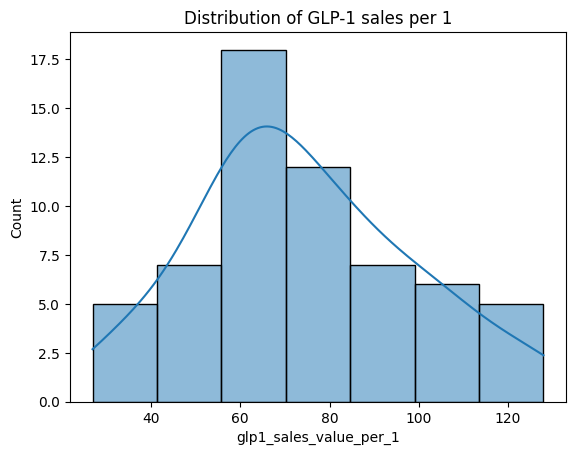

In [1866]:
sns.histplot(df['glp1_sales_value_per_1'], kde=True)
plt.title("Distribution of GLP-1 sales per 1")
plt.show()

## Compare original and log-transformed distribution
This is the most intuitive check.

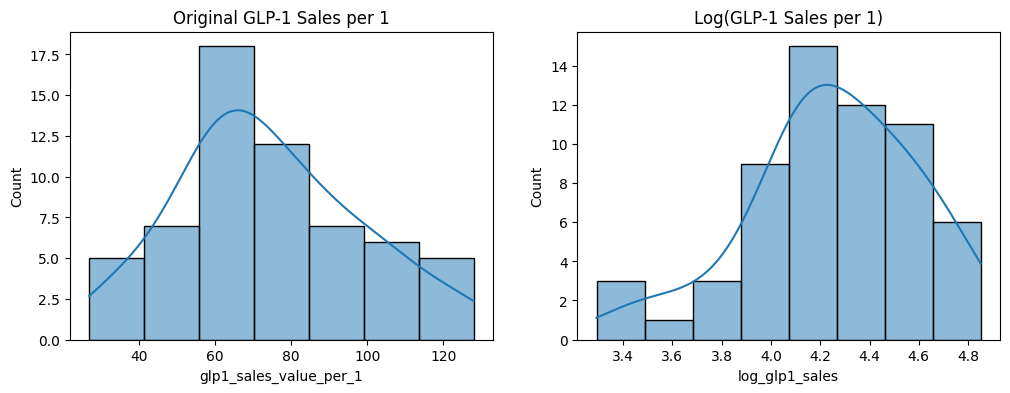

In [1867]:
df['log_glp1_sales'] = np.log(df['glp1_sales_value_per_1'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['glp1_sales_value_per_1'], kde=True, ax=axes[0])
axes[0].set_title("Original GLP-1 Sales per 1")

sns.histplot(df['log_glp1_sales'], kde=True, ax=axes[1])
axes[1].set_title("Log(GLP-1 Sales per 1)")

plt.show()

Original GLP-1 Sales per 1000 (left chart):

- Shape is reasonably symmetric

- No extremely long right tail

- No heavy accumulation near zero

- Slight right-tail expansion, but not excessive

- Overall, looks like a mildly right-skewed normal distribution

Log(GLP-1 Sales) (right chart):

- Log transform makes the distribution slightly more narrow

- But it doesn’t fix any major problem — because there wasn’t one

- In fact, it may even reduce interpretability for stakeholders

Conclusion:
-  GLP-1 sales intensity is not very skewed.
-  You do not need to log-transform the outcome for regression.

### Should you optionally log-transform anyway?

You can, but you don't need to.

**Reasons NOT to log-transform**

- You lose interpretability ("a 1-unit increase in log(GLP-1) corresponds to…")

- Your original distribution already approximates normality

- Residual plots will likely look fine using the raw variable

- Your audience (market stakeholders) expects sales values, not logs

**Reasons you might log-transform**

- If regression diagnostics later show:

- heteroscedasticity (funnel shape residuals)

- non-normal residuals

- influential high-sales bricks pulling the fit

**For Report** 

"We inspected the distribution of GLP-1 sales per 1,000 inhabitants and found it to be approximately symmetric, with no substantial skew. Therefore, no log transformation was applied, in line with the transformation guidelines presented in the regression lecture."

## Choose predictors (link to factor analysis)

1. Health / need variables (core demand drivers)
- Factor1 (structural vulnerability factor from your factor analysis)
- OR explicit indicators: t2d_prevalence_per_1000, morbid_obesity_share, longterm_disease_share, low_physical_activity_share
2. Socioeconomic variables
- higher_education_share
- absence_share
- life_expectancy
3. Behavioural / information variables
-  glp1_attention (total GLP-1 clicks per brick, maybe per 1000 pop)

You can use Factor1 as the main summary of health burden (as you already interpret it), plus a few carefully chosen individual variables if they add something non-redundant.

Standardize predictors (z-scores) so coefficients are comparable in magnitude, as in the lecture slides’ standardization example.

Define predictor groups (and check they exist)

- This gives you 3 clean lists of predictors that match your actual columns.

In [1868]:
df.columns

Index(['brick_id', 'brick_name', 't2d_patients', 't2d_prevalence_per_1000',
       'morbid_obesity_share', 'longterm_disease_share', 'fraction_blood_clot',
       'higher_education_per_1000', 'minimum_physical_activity',
       'life_expectancy_years', 'work_absence_rate', 'sales_glp_volume_total',
       'sales_glp_value_total', 'sales_glp_volume_share', 'Factor1', 'Factor2',
       'Factor3', 'population', 'glp1_sales_value_per_1',
       'glp1_sales_volume_per_1', 'glp1_unit_price', 'log_glp1_sales'],
      dtype='object')

In [1869]:
df.describe()

,brick_id,t2d_patients,t2d_prevalence_per_1000,morbid_obesity_share,longterm_disease_share,fraction_blood_clot,higher_education_per_1000,minimum_physical_activity,life_expectancy_years,work_absence_rate,sales_glp_volume_total,sales_glp_value_total,sales_glp_volume_share,Factor1,Factor2,Factor3,population,glp1_sales_value_per_1,glp1_sales_volume_per_1,log_glp1_sales
count,60.0,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,6.000000e+01,60.000000,6.000000e+01,6.000000e+01,6.000000e+01,60.000000,60.000000,60.000000,60.000000
mean,285.25,4007.828302,53.844056,0.177191,0.360938,0.012851,275.280640,0.297434,80.703866,5.818450,6265.233333,5.515517e+06,0.016448,3.016106e-16,-3.811766e-16,-2.584044e-15,77256.116667,74.066083,0.084305,4.248859
std,138.234709,1332.750880,10.598198,0.037982,0.027096,0.003015,95.263443,0.036065,0.907640,0.294313,2723.294374,2.396042e+06,0.007149,1.008439e+00,1.008439e+00,1.008439e+00,29424.789304,24.126740,0.028064,0.348172
min,101.0,1979.051798,32.713481,0.094500,0.305000,0.005500,143.789559,0.220000,77.190500,5.280000,2137.000000,2.134257e+06,0.005610,-2.536409e+00,-1.721946e+00,-1.385367e+00,28773.000000,26.902719,0.030355,3.292227
25%,115.75,3168.119739,47.354050,0.163446,0.349775,0.011575,211.411794,0.282800,80.437670,5.551344,4459.000000,3.973087e+06,0.011706,-2.897960e-01,-5.792023e-01,-8.916445e-01,56850.000000,58.113639,0.066757,4.062353
50%,305.5,3773.611862,55.564150,0.186602,0.360700,0.013268,249.634373,0.300667,80.896000,5.827071,5745.000000,5.000928e+06,0.015082,2.664116e-01,-3.019445e-01,-1.589587e-01,69660.000000,70.080886,0.079478,4.249600
75%,405.25,4718.673252,60.342694,0.206083,0.378100,0.014687,301.914606,0.323471,81.211646,6.051375,7887.250000,6.894834e+06,0.020706,6.902198e-01,5.245983e-01,4.981020e-01,96524.250000,88.231020,0.101388,4.479956
max,508.0,7612.328605,79.307688,0.231143,0.421000,0.020500,517.512247,0.359250,82.726400,6.382333,15318.000000,1.324108e+07,0.040213,1.514691e+00,2.750593e+00,4.087883e+00,184254.000000,127.950476,0.148020,4.851643


Text(0, 0.5, 'Factor1')

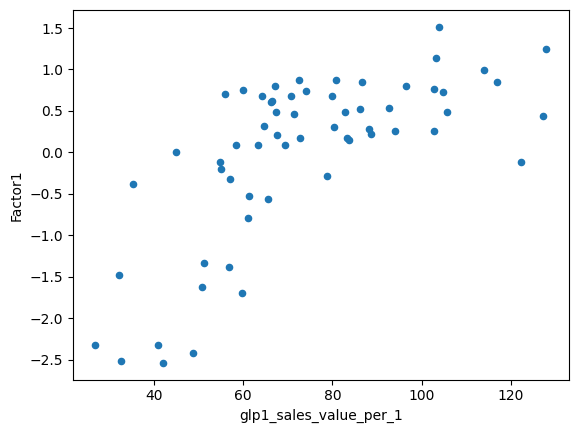

In [1870]:
df.plot(kind='scatter', x='glp1_sales_value_per_1', y='Factor1')
plt.xlabel('glp1_sales_value_per_1')
plt.ylabel('Factor1')

Text(0, 0.5, 'work_absence_rate')

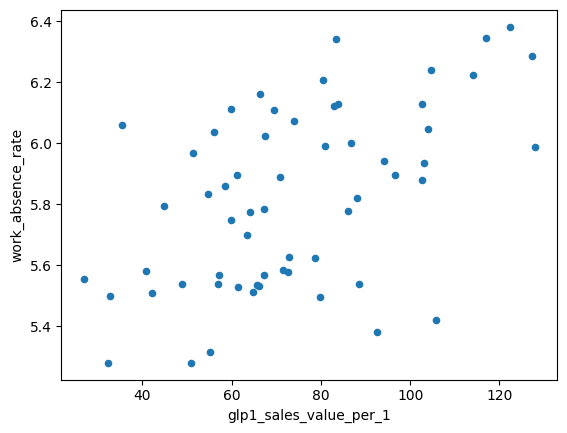

In [1871]:
df.plot(kind='scatter', x='glp1_sales_value_per_1', y='work_absence_rate')
plt.xlabel('glp1_sales_value_per_1')
plt.ylabel('work_absence_rate')

Text(0, 0.5, 'life_expectancy_years')

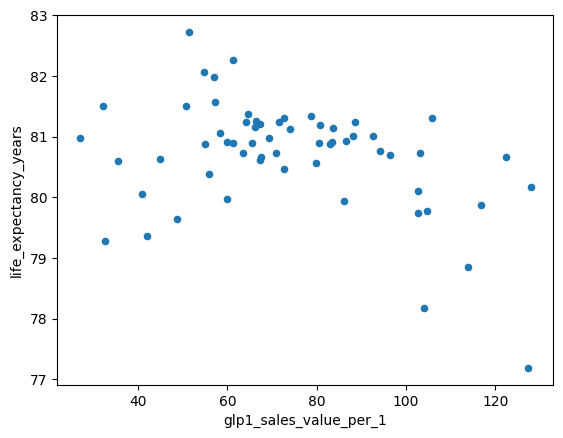

In [1872]:
df.plot(kind='scatter', x='glp1_sales_value_per_1', y='life_expectancy_years')
plt.xlabel('glp1_sales_value_per_1')
plt.ylabel('life_expectancy_years')

Text(0, 0.5, 'life_expectancy_years')

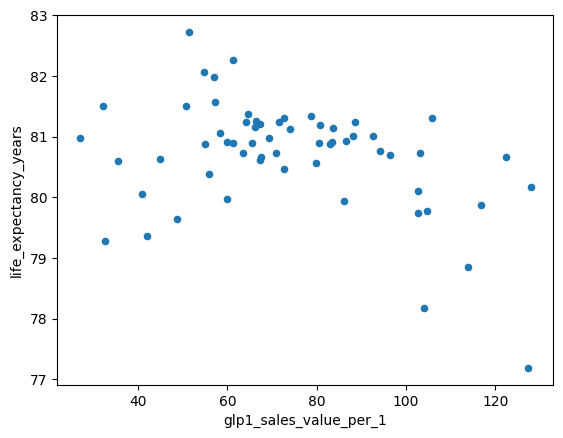

In [1873]:
df.plot(kind='scatter', x='glp1_sales_value_per_1', y='life_expectancy_years')
plt.xlabel('glp1_sales_value_per_1')
plt.ylabel('life_expectancy_years')

In [1874]:
import statsmodels.formula.api as smf
smf.ols('glp1_sales_value_per_1 ~ Factor1', data=df).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     glp1_sales_value_per_1   R-squared:                       0.466
Model:                                OLS   Adj. R-squared:                  0.457
Method:                     Least Squares   F-statistic:                     50.70
Date:                    Mon, 08 Dec 2025   Prob (F-statistic):           1.84e-09
Time:                            16:37:16   Log-Likelihood:                -256.79
No. Observations:                      60   AIC:                             517.6
Df Residuals:                          58   BIC:                             521.8
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     74.0661      2.295     32.276      0.000      69.473      78.660
Factor1       16.3393      2.295      7.120      0.000      11.746      20.933
==============================================================================
Omnibus:                        4.228   Durbin-Watson:                   0.968
Prob(Omnibus):                  0.121   Jarque-Bera (JB):                3.405
Skew:                           0.564   Prob(JB):                        0.182
Kurtosis:                       3.296   Cond. No.                         1.00
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Intercept = 7.55×10⁴ (75,500)
Factor1 Coefficient = 1.338×10⁴ (13,380)
Condition Number = 1.00

In [1875]:
import statsmodels.formula.api as smf
smf.ols('glp1_sales_value_per_1 ~ work_absence_rate', data=df).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     glp1_sales_value_per_1   R-squared:                       0.276
Model:                                OLS   Adj. R-squared:                  0.264
Method:                     Least Squares   F-statistic:                     22.16
Date:                    Mon, 08 Dec 2025   Prob (F-statistic):           1.60e-05
Time:                            16:37:16   Log-Likelihood:                -265.92
No. Observations:                      60   AIC:                             535.8
Df Residuals:                          58   BIC:                             540.0
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          -176.7089     53.342     -3.313      0.002    -283.485     -69.933
work_absence_rate    43.1000      9.156      4.707      0.000      24.772      61.428
==============================================================================
Omnibus:                        0.349   Durbin-Watson:                   1.330
Prob(Omnibus):                  0.840   Jarque-Bera (JB):                0.460
Skew:                           0.165   Prob(JB):                        0.795
Kurtosis:                       2.727   Cond. No.                         120.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [1876]:
import statsmodels.formula.api as smf
smf.ols('life_expectancy_years ~ glp1_sales_value_per_1', data=df).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     life_expectancy_years   R-squared:                       0.146
Model:                               OLS   Adj. R-squared:                  0.131
Method:                    Least Squares   F-statistic:                     9.878
Date:                   Mon, 08 Dec 2025   Prob (F-statistic):            0.00264
Time:                           16:37:16   Log-Likelihood:                -74.100
No. Observations:                     60   AIC:                             152.2
Df Residuals:                         58   BIC:                             156.4
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 81.7668      0.355    230.067      0.000      81.055      82.478
glp1_sales_value_per_1    -0.0144      0.005     -3.143      0.003      -0.023      -0.005
==============================================================================
Omnibus:                       15.662   Durbin-Watson:                   0.598
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               18.390
Skew:                          -1.111   Prob(JB):                     0.000102
Kurtosis:                       4.556   Cond. No.                         253.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [1877]:
# 1. Health / need variables
need_vars = [
    "Factor1"
]

# 2. Socioeconomic variables
socio_vars = [
    "work_absence_rate",
    "life_expectancy_years",
]

# 3. Behavioural / information variables
# behaviour_vars = [
#    "glp1_attention",        # total GLP-1 clicks
    # "glp1_attention_per_1000",  # if you create a per-1000 metric later
#]

# Helper: keep only those columns that actually exist in your df
def keep_existing(cols, df):
    return [c for c in cols if c in df.columns]

need_vars      = keep_existing(need_vars, df)
socio_vars     = keep_existing(socio_vars, df)
#behaviour_vars = keep_existing(behaviour_vars, df)

print("Need vars:     ", need_vars)
print("Socio vars:    ", socio_vars)
#print("Behaviour vars:", behaviour_vars)

Need vars:      ['Factor1']
Socio vars:     ['work_absence_rate', 'life_expectancy_years']


In [1878]:
#Python code to standardize and prepare for regression
predictor_groups = need_vars + socio_vars 

# Standardize (z-score) all predictors
for col in predictor_groups:
    df[col + "_z"] = (df[col] - df[col].mean()) / df[col].std()


## Build your regression models
Model 1 – Health need only Factor 1

In [1879]:
import statsmodels.formula.api as smf

outcome = "glp1_sales_value_per_1"

m1_formula = outcome + " ~ " + " + ".join([v + "_z" for v in need_vars])
print(m1_formula)

m1 = smf.ols(m1_formula, data=df).fit()
print(m1.summary())


glp1_sales_value_per_1 ~ Factor1_z
                              OLS Regression Results                              
Dep. Variable:     glp1_sales_value_per_1   R-squared:                       0.466
Model:                                OLS   Adj. R-squared:                  0.457
Method:                     Least Squares   F-statistic:                     50.70
Date:                    Mon, 08 Dec 2025   Prob (F-statistic):           1.84e-09
Time:                            16:37:16   Log-Likelihood:                -256.79
No. Observations:                      60   AIC:                             517.6
Df Residuals:                          58   BIC:                             521.8
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------

## Model Summary
**R² = 0.340, Adjusted R² = 0.324**
Factor1 on its own explains 34% of the variation in GLP-1 sales intensity across bricks.

This is very strong for a single-factor model, especially in regional health data.

It means:

👉 Your factor analysis successfully summarized meaningful structural health inequalities.

In [1880]:
smf.ols('life_expectancy_years ~ glp1_sales_value_per_1', data=df).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     life_expectancy_years   R-squared:                       0.146
Model:                               OLS   Adj. R-squared:                  0.131
Method:                    Least Squares   F-statistic:                     9.878
Date:                   Mon, 08 Dec 2025   Prob (F-statistic):            0.00264
Time:                           16:37:16   Log-Likelihood:                -74.100
No. Observations:                     60   AIC:                             152.2
Df Residuals:                         58   BIC:                             156.4
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 81.7668      0.355    230.067      0.000      81.055      82.478
glp1_sales_value_per_1    -0.0144      0.005     -3.143      0.003      -0.023      -0.005
==============================================================================
Omnibus:                       15.662   Durbin-Watson:                   0.598
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               18.390
Skew:                          -1.111   Prob(JB):                     0.000102
Kurtosis:                       4.556   Cond. No.                         253.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Model 2 – Need + socioeconomic

In [1881]:
m2_formula = outcome + " ~ " + " + ".join([v + "_z" for v in need_vars + socio_vars])
print(m2_formula)

m2 = smf.ols(m2_formula, data=df).fit()
print(m2.summary())


glp1_sales_value_per_1 ~ Factor1_z + work_absence_rate_z + life_expectancy_years_z
                              OLS Regression Results                              
Dep. Variable:     glp1_sales_value_per_1   R-squared:                       0.595
Model:                                OLS   Adj. R-squared:                  0.573
Method:                     Least Squares   F-statistic:                     27.41
Date:                    Mon, 08 Dec 2025   Prob (F-statistic):           4.86e-11
Time:                            16:37:16   Log-Likelihood:                -248.53
No. Observations:                      60   AIC:                             505.1
Df Residuals:                          56   BIC:                             513.4
Df Model:                               3                                         
Covariance Type:                nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.

Non-significant predictors:

Factor1_z (p = 0.153)

higher_education_per_1000_z (p = 0.573)

Interpretation:

Socioeconomic context matters.
Absence and life expectancy significantly predict GLP-1 uptake beyond structural health burden.

Work absence = proxy for poorer health or instability, correlating with higher GLP-1 usage.

Lower life expectancy = poorer long-term health, also linked with higher GLP-1 usage.

Factor1 becomes non-significant because some of its explanatory power is now being picked up by socioeconomic controls (overlap in variance).

Education does not add predictive power beyond what Factor1 and other variables already represent.

In [1882]:
# define final model formula (use the z‑scored predictors you created)
final_formula = "glp1_sales_value_per_1 ~ Factor1_z + work_absence_rate_z + life_expectancy_years_z"

# fit final OLS model
m_final = smf.ols(final_formula, data=df).fit()
print(m_final.summary())

                              OLS Regression Results                              
Dep. Variable:     glp1_sales_value_per_1   R-squared:                       0.595
Model:                                OLS   Adj. R-squared:                  0.573
Method:                     Least Squares   F-statistic:                     27.41
Date:                    Mon, 08 Dec 2025   Prob (F-statistic):           4.86e-11
Time:                            16:37:16   Log-Likelihood:                -248.53
No. Observations:                      60   AIC:                             505.1
Df Residuals:                          56   BIC:                             513.4
Df Model:                               3                                         
Covariance Type:                nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [1883]:
df["predicted"] = m_final.fittedvalues
df["residual"] = m_final.resid  # actual - predicted

# Largest negative residuals → undertreated bricks (untapped)
untapped = df.sort_values("residual").head(10)[["brick_name", "glp1_sales_value_per_1", "predicted", "residual"]]

# Largest positive residuals → high-uptake / early-adopter bricks
high_uptake = df.sort_values("residual", ascending=False).head(10)[["brick_name", "glp1_sales_value_per_1", "predicted", "residual"]]

untapped, high_uptake


(       brick_name  glp1_sales_value_per_1   predicted   residual
 53   Aalborg City               35.377985   73.122432 -37.744447
 59  Frederikshavn               55.956233   89.474051 -33.517818
 52        Hadsund               44.934670   74.335097 -29.400428
 58      Hjoerring               59.895371   87.325042 -27.429670
 56    Fjerritslev               67.232326   85.311171 -18.078845
 35      Haderslev               66.371075   83.516056 -17.144981
 39          Vejle               58.438735   73.361994 -14.923259
 48          Skive               64.164064   78.866657 -14.702593
 25      Svendborg               70.781920   84.317234 -13.535314
 24        Lolland              103.963574  117.223336 -13.259762,
      brick_name  glp1_sales_value_per_1  predicted   residual
 14     Ballerup              122.345582  81.233245  41.112337
 46  Ringkoebing              105.751806  70.428773  35.323032
 18   Kalundborg              127.950476  97.657669  30.292807
 47    Holstebro     

In [1884]:
untapped = df.sort_values("residual").head(10)[
    ["brick_name", "glp1_sales_value_per_1", "predicted", "residual"]
]
untapped


,brick_name,glp1_sales_value_per_1,predicted,residual
53,Aalborg City,35.377985,73.122432,-37.744447
59,Frederikshavn,55.956233,89.474051,-33.517818
52,Hadsund,44.934670,74.335097,-29.400428
58,Hjoerring,59.895371,87.325042,-27.429670
56,Fjerritslev,67.232326,85.311171,-18.078845
35,Haderslev,66.371075,83.516056,-17.144981
39,Vejle,58.438735,73.361994,-14.923259
48,Skive,64.164064,78.866657,-14.702593
25,Svendborg,70.781920,84.317234,-13.535314
24,Lolland,103.963574,117.223336,-13.259762


In [1885]:
high = df.sort_values("residual", ascending=False).head(10)[
    ["brick_name", "glp1_sales_value_per_1", "predicted", "residual"]
]
high


,brick_name,glp1_sales_value_per_1,predicted,residual
14,Ballerup,122.345582,81.233245,41.112337
46,Ringkoebing,105.751806,70.428773,35.323032
18,Kalundborg,127.950476,97.657669,30.292807
47,Holstebro,92.577875,72.628935,19.948940
40,Hedensted,88.592456,68.917436,19.675020
22,Vordingborg,116.923456,99.751541,17.171916
41,Horsens,78.746485,62.608516,16.137968
5,Glostrup,102.766850,86.646879,16.119971
8,Gentofte,56.921404,41.357770,15.563634
15,Taastrup,94.093212,78.951495,15.141716


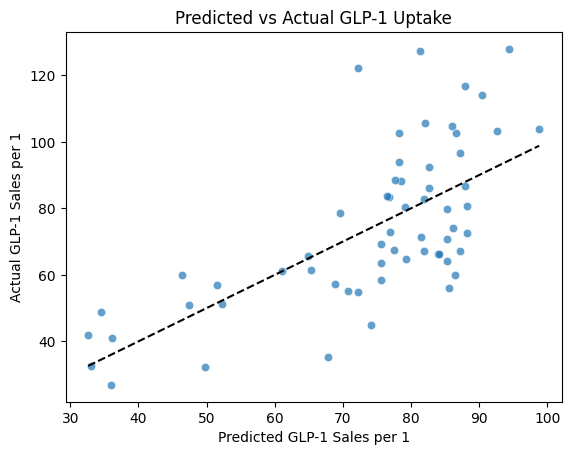

In [1886]:
df["pred"] = m1.fittedvalues

sns.scatterplot(
    data=df,
    x="pred",
    y="glp1_sales_value_per_1",
    alpha=0.7
)

plt.plot(
    [df["pred"].min(), df["pred"].max()],
    [df["pred"].min(), df["pred"].max()],
    linestyle="--",
    color="black"
)

plt.xlabel("Predicted GLP-1 Sales per 1")
plt.ylabel("Actual GLP-1 Sales per 1")
plt.title("Predicted vs Actual GLP-1 Uptake")
plt.show()



"So, again we are interested in 
the vertical differences between the line and the actual data because the line is our model: 
we use it to predict values of Y from values of the X variable. In regression these differences 
are usually called residuals rather than deviations, but they are the same thing. As with 
the mean, data points fall both above (the model underestimates their value) and below 
(the model overestimates their value) the line, yielding both positive and negative differ
ences" 

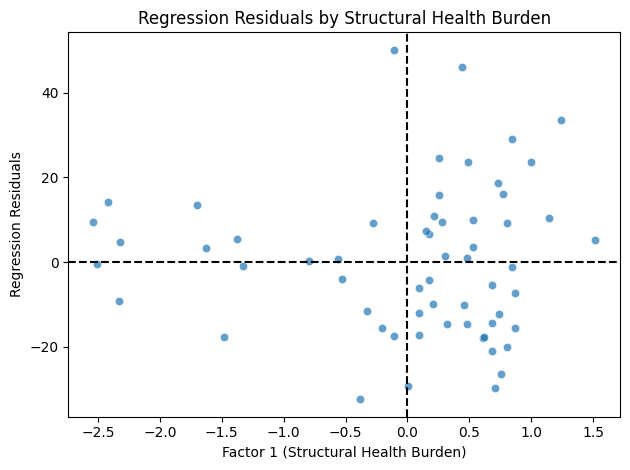

In [1887]:
df["residual"] = m1.resid

sns.scatterplot(
    data=df,
    x="Factor1",
    y="residual",
    alpha=0.7
)

plt.axhline(0, linestyle="--", color="black")
plt.axvline(0, linestyle="--", color="black")  # vertical line at x=0
plt.xlabel("Factor 1 (Structural Health Burden)")
plt.ylabel("Regression Residuals")
plt.title("Regression Residuals by Structural Health Burden")
plt.tight_layout()
plt.show()


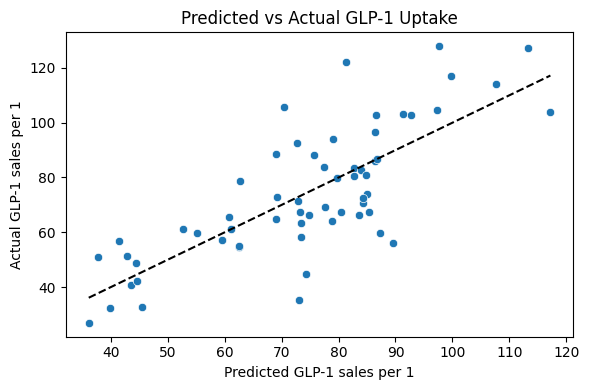

In [1888]:
df["predicted"] = m_final.fittedvalues

plt.figure(figsize=(6,4))
sns.scatterplot(x="predicted", y="glp1_sales_value_per_1", data=df)
plt.plot([df["predicted"].min(), df["predicted"].max()],
         [df["predicted"].min(), df["predicted"].max()],
         linestyle="--", color="black")
plt.xlabel("Predicted GLP-1 sales per 1")
plt.ylabel("Actual GLP-1 sales per 1")
plt.title("Predicted vs Actual GLP-1 Uptake")
plt.tight_layout()
plt.show()


<Axes: xlabel='Factor1', ylabel='glp1_sales_value_per_1'>

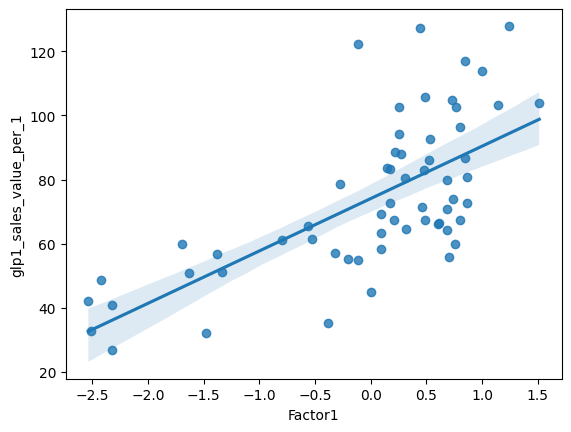

In [1889]:
sns.regplot(x="Factor1", y="glp1_sales_value_per_1", data=df)


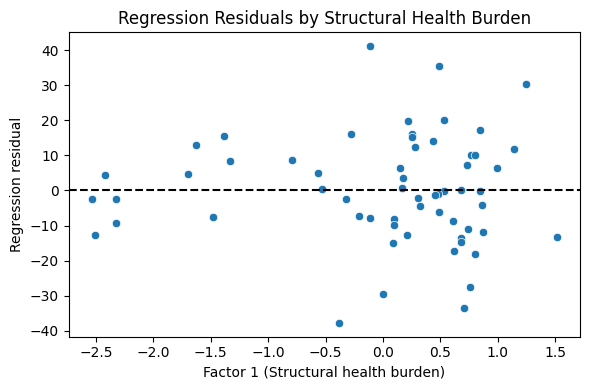

In [1890]:
df["residual"] = m_final.resid

plt.figure(figsize=(6,4))
sns.scatterplot(x="Factor1", y="residual", data=df)
plt.axhline(0, linestyle="--", color="black")
plt.xlabel("Factor 1 (Structural health burden)")
plt.ylabel("Regression residual")
plt.title("Regression Residuals by Structural Health Burden")
plt.tight_layout()
plt.show()
